<a href="https://colab.research.google.com/github/Bukunmi2108/ml-journey/blob/main/research/p2/quant.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Quantization from scratch

In [346]:
import time
import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import seaborn as sns
import torch.nn.functional as F
import urllib.request as req
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModelForCausalLM

In [347]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_id = "HuggingFaceTB/SmolLM2-135M"
tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForCausalLM.from_pretrained(model_id).to(device)

Loading weights:   0%|          | 0/272 [00:00<?, ?it/s]

In [348]:
if tokenizer.pad_token is None:
  tokenizer.pad_token = tokenizer.eos_token

In [349]:
class INTQuantizer():
  @staticmethod
  def quantize_int8_per_tensor(tensor: torch.Tensor):
    scale = tensor.abs().max() / 127
    scale = scale.clamp(min=1e-8)
    out = torch.round(tensor / scale).clamp(-128, 127).to(torch.int8)
    return out, scale

  @staticmethod
  def dequantize_int8_per_tensor(q_tensor: torch.Tensor, scale: torch.Tensor):
    return q_tensor.float() * scale

  @staticmethod
  def quantize_int8_per_channel(tensor: torch.Tensor): # quantizes/scales per row
    scales = tensor.abs().amax(dim=1, keepdim=True) / 127
    scales = scales.clamp(min=1e-8)
    out = torch.round(tensor / scales).clamp(-127, 127).to(torch.int8)
    return out, scales

  @staticmethod
  def dequantize_int8_per_channel(q_tensor: torch.Tensor, scales: torch.Tensor):
    return q_tensor.float() * scales

  @staticmethod
  def quantize_int4_groupwise(tensor: torch.Tensor, group_size = 128):
    out_dim, in_dim = tensor.shape
    pad = (group_size - (in_dim % group_size)) % group_size
    if pad:
      T_padded = F.pad(tensor, (0, pad))
    else:
      T_padded = tensor
    padded_dim = T_padded.shape[1]
    T_reshaped = T_padded.view(out_dim, padded_dim // group_size, group_size)

    scales = T_reshaped.abs().amax(dim=2, keepdim=True) / 7
    scales = scales.clamp(min=1e-8)
    out = torch.round(T_reshaped / scales).clamp(-8, 7).to(torch.int8)

    meta = {
        "original_shape": tensor.shape,
        "padded_shape": T_padded.shape,
        "group_size": group_size,
        "pad": pad
    }

    return out, scales, meta

  @staticmethod
  def dequantize_int4_groupwise(q_tensor: torch.Tensor, scales: torch.Tensor, meta: dict):
    T_padded_hat = (q_tensor.float() * scales).view(meta["padded_shape"])
    out_dim, in_dim = meta["original_shape"]
    return T_padded_hat[:, :in_dim]

  @staticmethod
  def tensor_error(tensor: torch.Tensor, tensor_hat: torch.Tensor):
    mse = torch.mean((tensor - tensor_hat) ** 2).item()
    mae = torch.mean(torch.abs(tensor - tensor_hat)).item()
    max_err = torch.max(torch.abs(tensor -tensor_hat)).item()
    rel_mse = mse / (torch.mean(tensor ** 2).item() + 1e-12)
    return mse, mae, max_err, rel_mse

Test INTQuantizer class

In [350]:
iq = INTQuantizer()
test_tensor = torch.tensor([-10.0, 0.0, 5.0, 10.0])

quantized_tensor, scale = iq.quantize_int8_per_tensor(test_tensor)
assert torch.isclose(scale, torch.tensor(10.0/127.0))

dequantized_tensor = iq.dequantize_int8_per_tensor(quantized_tensor, scale)
assert torch.allclose(test_tensor, dequantized_tensor, atol=scale.item()/2)

In [351]:
test_tensor = torch.tensor([[-10., 0., 5., 10.], [-20., -5., 0., 15.]])
quantized_tensor, scales = iq.quantize_int8_per_channel(test_tensor)
dequantized_tensor = iq.dequantize_int8_per_channel(quantized_tensor, scales)
max_atol = scales.max().item() / 2
assert torch.allclose(test_tensor, dequantized_tensor, atol=max_atol)

In [352]:
test_tensor_groupwise = torch.randn(10, 256) * 10
group_size = 64

quantized_tensor_groupwise, scales_groupwise, meta_groupwise = iq.quantize_int4_groupwise(test_tensor_groupwise, group_size=group_size)
dequantized_tensor_groupwise = iq.dequantize_int4_groupwise(quantized_tensor_groupwise, scales_groupwise, meta_groupwise)
max_atol_groupwise = scales_groupwise.max().item() / 2
assert torch.allclose(test_tensor_groupwise, dequantized_tensor_groupwise, atol=max_atol_groupwise)

Quantizing Linear Layers

In [353]:
class QuantLinearInt8PerTensor(nn.Module):
  def __init__(self, linear: nn.Linear):
    super().__init__()
    qweight, scale = iq.quantize_int8_per_tensor(linear.weight)
    self.register_buffer("qweight", qweight)
    self.register_buffer("scale", scale)
    if linear.bias is not None:
      self.register_buffer("bias", linear.bias.data.clone())
    else:
      self.bias = None

  def forward(self, x: torch.Tensor):
    W = iq.dequantize_int8_per_tensor(self.qweight, self.scale).to(x.dtype)
    return F.linear(x, W, self.bias)

In [354]:
class QuantLinearInt8PerChannel(nn.Module):
  def __init__(self, linear: nn.Linear):
    super().__init__()
    qweight, scales = iq.quantize_int8_per_channel(linear.weight)
    self.register_buffer("qweight", qweight)
    self.register_buffer("scales", scales)
    if linear.bias is not None:
      self.register_buffer("bias", linear.bias.data.clone())
    else:
      self.bias = None

  def forward(self, x: torch.Tensor):
    W = iq.dequantize_int8_per_channel(self.qweight, self.scales).to(x.dtype)
    return F.linear(x, W, self.bias)

In [355]:
class QuantLinearInt4Groupwise(nn.Module):
  def __init__(self, linear: nn.Linear, group_size: int):
    super().__init__()
    qweight, scales, meta = iq.quantize_int4_groupwise(linear.weight, group_size)
    self.register_buffer("qweight", qweight)
    self.register_buffer("scales", scales)
    self.meta = meta
    if linear.bias is not None:
      self.register_buffer("bias", linear.bias.data.clone())
    else:
      self.bias = None

  def forward(self, x: torch.Tensor):
    W = iq.dequantize_int4_groupwise(self.qweight, self.scales, self.meta).to(x.dtype)
    return F.linear(x, W, self.bias)

Testing Quantizing Class

In [356]:
linear_layer = nn.Linear(10, 5)
quant_linear_layer = QuantLinearInt8PerTensor(linear_layer)

assert quant_linear_layer.qweight.dtype == torch.int8, "qweight should be int8"
assert quant_linear_layer.scale.dtype == torch.float, "scale should be float"

In [357]:
linear_layer_channel = nn.Linear(10, 5)
quant_linear_layer_channel = QuantLinearInt8PerChannel(linear_layer_channel)

assert quant_linear_layer_channel.qweight.dtype == torch.int8, "qweight should be int8 for per-channel"
assert quant_linear_layer_channel.scales.dtype == torch.float, "scales should be float for per-channel"

In [358]:
linear_layer_groupwise = nn.Linear(10, 5)
quant_linear_layer_groupwise = QuantLinearInt4Groupwise(linear_layer_groupwise, group_size=5)

assert quant_linear_layer_groupwise.qweight.dtype == torch.int8, "qweight should be int8 for groupwise"
assert quant_linear_layer_groupwise.scales.dtype == torch.float, "scales should be float for groupwise"
assert isinstance(quant_linear_layer_groupwise.meta, dict), "meta should be a dictionary for groupwise"

Replace Linear Layers with Quantized layers

In [359]:
def replace_linear_layers(module: nn.Module, scheme, group_size=128):
  for name, child in list(module.named_children()):
    if isinstance(child, nn.Linear):
      if scheme == "int8_per_tensor":
        setattr(module, name, QuantLinearInt8PerTensor(child))
      elif scheme == "int8_per_channel":
        setattr(module, name, QuantLinearInt8PerChannel(child))
      elif scheme == "int4_groupwise":
        setattr(module, name, QuantLinearInt4Groupwise(child, group_size))
      else:
        raise ValueError(f"Invalid scheme: {scheme}")
    else:
      replace_linear_layers(child, scheme, group_size)
  return module

In [360]:
import copy

def make_quantized_model(base_model, scheme, group_size=128):
  model = copy.deepcopy(base_model)
  model = replace_linear_layers(model, scheme, group_size)
  return model

Loading Text

In [361]:
url = "https://raw.githubusercontent.com/karpathy/char-rnn/master/data/tinyshakespeare/input.txt"

try:
    with req.urlopen(url) as response:
        raw_text = response.read().decode('utf-8')
    print("Total Length", len(raw_text))
except:
    print("Text download failed")

Total Length 1115394


Calculating Loss && Perplexity

In [362]:
@torch.no_grad()
def perplexity(model: nn.Module, texts, max_length=256):
  model.eval()

  enc = tokenizer(
      texts,
      return_tensors="pt",
      padding=True,
      truncation=True,
      max_length=max_length
  ).to(device)

  input_ids = enc["input_ids"]
  attention_mask = enc["attention_mask"]
  labels = input_ids.clone()
  labels[attention_mask == 0] = -100

  out = model(input_ids=input_ids, attention_mask=attention_mask, labels=labels)
  loss = out.loss
  perplexity = torch.exp(loss)
  return loss, perplexity

In [363]:
baseline_loss, baseline_perplexity = perplexity(model, raw_text)
perplexity_dict = {}
perplexity_dict["baseline"] = (baseline_loss.item(), baseline_perplexity.item())
print(f"Baseline Loss: {baseline_loss.item()}, Baseline Perplexity: {baseline_perplexity.item()}")

Baseline Loss: 3.333599090576172, Baseline Perplexity: 28.03907585144043


Test the Quantized models

Perplexity && Loss

In [364]:
q_model_int8_per_tensor = make_quantized_model(model, "int8_per_tensor")
q_model_int8_per_tensor = q_model_int8_per_tensor.to(device)
q_loss_int8_per_tensor, q_perplexity_int8_per_tensor = perplexity(q_model_int8_per_tensor, raw_text)
perplexity_dict["int8_per_tensor"] = (q_loss_int8_per_tensor.item(), q_perplexity_int8_per_tensor.item())
print(f"Quantized Loss (int8 per tensor): {q_loss_int8_per_tensor.item()}, Quantized Perplexity (int8 per tensor): {q_perplexity_int8_per_tensor.item()}")

Quantized Loss (int8 per tensor): 3.407289743423462, Quantized Perplexity (int8 per tensor): 30.18332862854004


In [365]:
q_model_int8_per_channel = make_quantized_model(model, "int8_per_channel")
q_model_int8_per_channel = q_model_int8_per_channel.to(device)
q_loss_int8_per_channel, q_perplexity_int8_per_channel = perplexity(q_model_int8_per_channel, raw_text)
perplexity_dict["int8_per_channel"] = (q_loss_int8_per_channel.item(), q_perplexity_int8_per_channel.item())
print(f"Quantized Loss (int8 per channel): {q_loss_int8_per_channel.item()}, Quantized Perplexity (int8 per channel): {q_perplexity_int8_per_channel.item()}")

Quantized Loss (int8 per channel): 3.329045534133911, Quantized Perplexity (int8 per channel): 27.91168785095215


In [366]:
q_model_int4_groupwise = make_quantized_model(model, "int4_groupwise")
q_model_int4_groupwise = q_model_int4_groupwise.to(device)
q_loss_int4_groupwise, q_perplexity_int4_groupwise = perplexity(q_model_int4_groupwise, raw_text)
perplexity_dict["int4_groupwise"] = (q_loss_int4_groupwise.item(), q_perplexity_int4_groupwise.item())
print(f"Quantized Loss (int4 groupwise): {q_loss_int4_groupwise.item()}, Quantized Perplexity (int4 groupwise): {q_perplexity_int4_groupwise.item()}")

Quantized Loss (int4 groupwise): 3.9061226844787598, Quantized Perplexity (int4 groupwise): 49.70585250854492


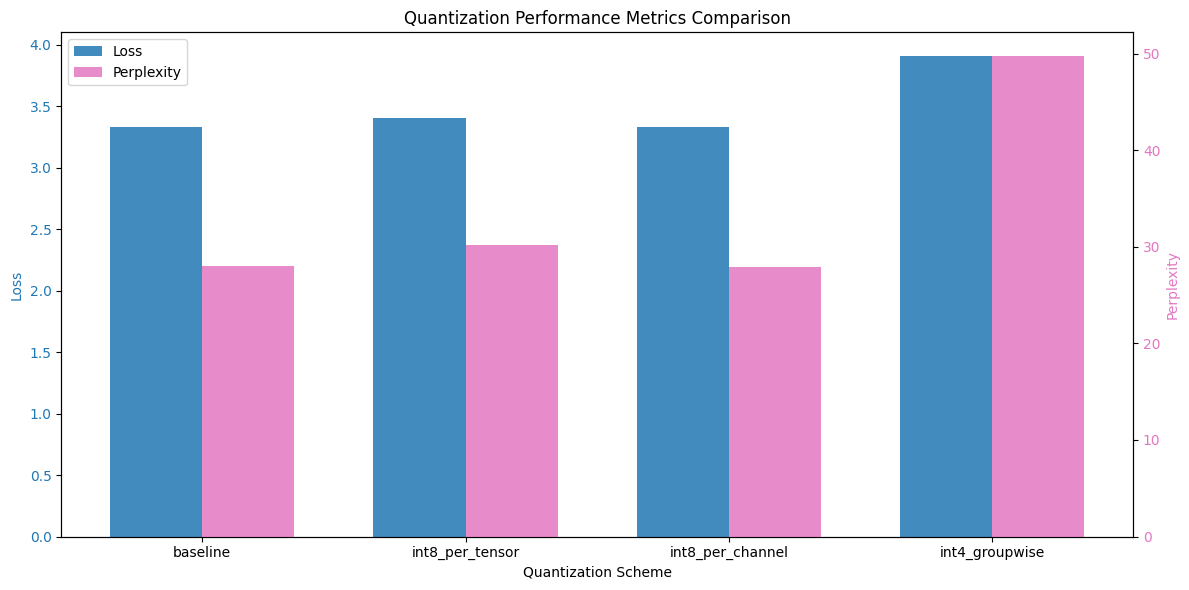

In [367]:
schemes = list(perplexity_dict.keys())
losses = [x[0] for x in perplexity_dict.values()]
perplexities = [x[1] for x in perplexity_dict.values()]

x = np.arange(len(schemes))
width = 0.35
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary Y-Axis (Loss)
rects1 = ax1.bar(x - width/2, losses, width, label='Loss', color='#1f77b4', alpha=0.85)
ax1.set_ylabel('Loss', color='#1f77b4')
ax1.tick_params(axis='y', labelcolor='#1f77b4')

# Secondary Y-Axis (Perplexity)
ax2 = ax1.twinx()
rects2 = ax2.bar(x + width/2, perplexities, width, label='Perplexity', color='#e377c2', alpha=0.85)
ax2.set_ylabel('Perplexity', color='#e377c2')
ax2.tick_params(axis='y', labelcolor='#e377c2')

# Styling adjustments
ax1.set_xlabel('Quantization Scheme')
ax1.set_title('Quantization Performance Metrics Comparison')
ax1.set_xticks(x)
ax1.set_xticklabels(schemes)

# Combined Legend
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc='upper left')

plt.tight_layout()
plt.show()


Storage && Memory Benchmarking

In [368]:
def get_model_size_in_mb(model: nn.Module):
  total_params = 0
  total_buffers = 0
  for param in model.parameters():
    total_params += param.numel() * param.element_size()
  for buffer in model.buffers():
    total_buffers += buffer.numel() * buffer.element_size()
  total_size_bytes = total_params + total_buffers
  return total_size_bytes / (1024 * 1024)

In [369]:
model_sizes_mb = {}
model_sizes_mb["baseline"] = get_model_size_in_mb(model)
model_sizes_mb["int8_per_tensor"] = get_model_size_in_mb(q_model_int8_per_tensor)
model_sizes_mb["int8_per_channel"] = get_model_size_in_mb(q_model_int8_per_channel)
model_sizes_mb["int4_groupwise"] = get_model_size_in_mb(q_model_int4_groupwise)

print("Model Sizes (MB):")
for scheme, size in model_sizes_mb.items():
    print(f"  {scheme}: {size:.4f} MB")

Model Sizes (MB):
  baseline: 256.5673 MB
  int8_per_tensor: 182.3177 MB
  int8_per_channel: 182.7076 MB
  int4_groupwise: 195.9374 MB


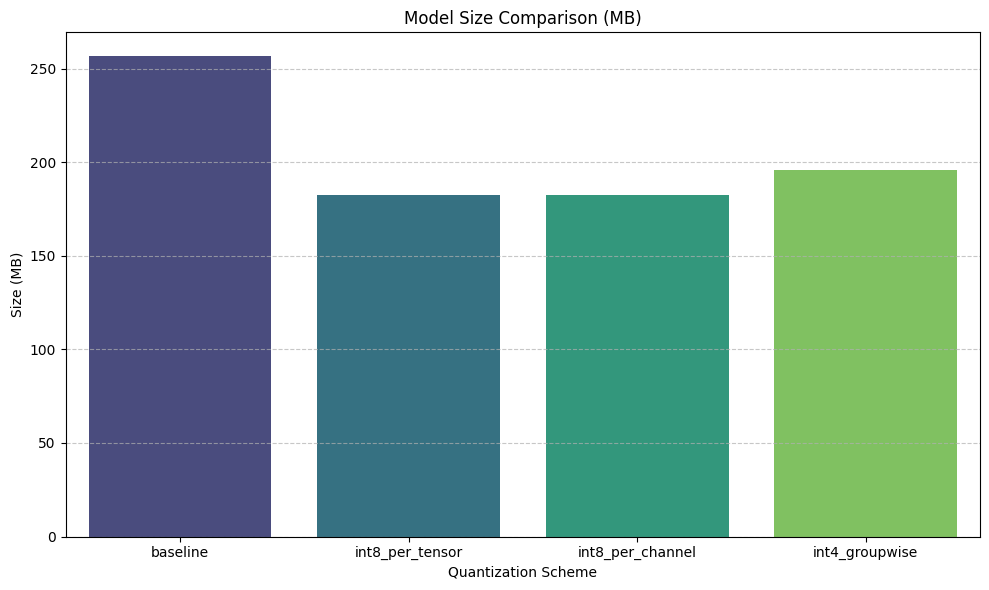

In [370]:
size_df = pd.DataFrame(model_sizes_mb.items(), columns=['Quantization Scheme', 'Size (MB)'])
fig = plt.figure(figsize=(10, 6))
sns.barplot(x='Quantization Scheme', y='Size (MB)', data=size_df, hue='Quantization Scheme', legend=False, palette='viridis')
plt.title('Model Size Comparison (MB)')
plt.xlabel('Quantization Scheme')
plt.ylabel('Size (MB)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Latency

In [371]:
models_to_test = {
    "baseline": model,
    "int8_per_tensor": q_model_int8_per_tensor,
    "int8_per_channel": q_model_int8_per_channel,
    "int4_groupwise": q_model_int4_groupwise,
}

latency_results = {}
latency_test_prompt = "Who is Williams Shakespeare in one sentence?"
inputs = tokenizer(latency_test_prompt, return_tensors="pt").to(device)

for name, current_model in models_to_test.items():
    print(f"\nTesting latency for {name} model...")
    current_model.eval()

    # Warm-up run
    with torch.no_grad():
        _ = current_model.generate(**inputs, max_new_tokens=20, pad_token_id=tokenizer.eos_token_id)
    start_time = time.perf_counter()

    with torch.no_grad():
        outputs = current_model.generate(**inputs, max_new_tokens=20, pad_token_id=tokenizer.eos_token_id)
    end_time = time.perf_counter()

    total_time = end_time - start_time
    num_output_tokens = len(outputs[0]) - len(inputs['input_ids'][0])
    tokens_per_second = num_output_tokens / total_time

    latency_results[name] = {
        "Total Time (s)": total_time,
        "Num Output Tokens": num_output_tokens,
        "Tokens per Second": tokens_per_second,
    }

    print(f"  Total Time: {total_time:.4f} seconds")
    print(f"  Number of Output Tokens: {num_output_tokens}")
    print(f"  Tokens per Second: {tokens_per_second:.2f}")


Testing latency for baseline model...
  Total Time: 0.7656 seconds
  Number of Output Tokens: 20
  Tokens per Second: 26.12

Testing latency for int8_per_tensor model...
  Total Time: 1.0573 seconds
  Number of Output Tokens: 20
  Tokens per Second: 18.92

Testing latency for int8_per_channel model...
  Total Time: 1.3351 seconds
  Number of Output Tokens: 20
  Tokens per Second: 14.98

Testing latency for int4_groupwise model...
  Total Time: 1.1892 seconds
  Number of Output Tokens: 20
  Tokens per Second: 16.82


In [372]:
latency_df = pd.DataFrame.from_dict(latency_results, orient='index')
display(latency_df)

,Total Time (s),Num Output Tokens,Tokens per Second
baseline,0.765642,20,26.121856
int8_per_tensor,1.057289,20,18.916300
int8_per_channel,1.335062,20,14.980575
int4_groupwise,1.189167,20,16.818501


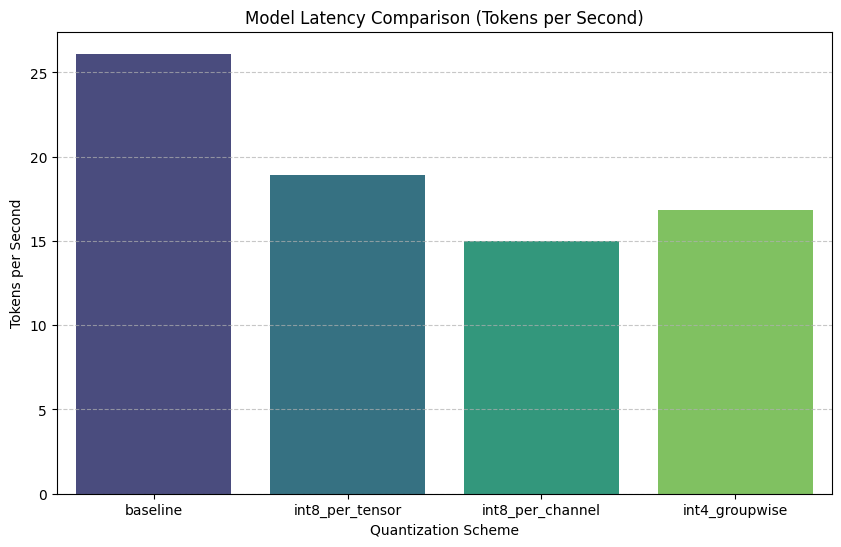

In [373]:
fig = plt.figure(figsize=(10, 6))
sns.barplot(x=latency_df.index, y='Tokens per Second', data=latency_df, hue=latency_df.index, legend=False, palette='viridis')
plt.title('Model Latency Comparison (Tokens per Second)')
plt.xlabel('Quantization Scheme')
plt.ylabel('Tokens per Second')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()